In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from particletracker.fileparser import field_function_from_file

In [18]:


def field_plot(df):

    def field_plot_2d(df, component='Bx', res=(500, 600), y_fixed=None):


        B_field = field_function_from_file('2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=2.5A_ID=5481.dat', separator='\t', data_start=17)

        df = df.copy()
        for col in ['x_mm', 'y_mm', 'z_mm', 'Bx_T', 'By_T', 'Bz_T']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.dropna()
        # Get unique coordinate values
        x_vals = np.sort(df["x_mm"].unique())
        y_vals = np.sort(df["y_mm"].unique())
        z_vals = np.sort(df["z_mm"].unique())
        
        # Set y coordinate if not provided
        if y_fixed is None:
            y_fixed = y_vals[0]
        
        # Filter original data for this y-plane
        df_plane = df[np.isclose(df['y_mm'], y_fixed, atol=1e-6)]
        
        # Create figure with 2 subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot 1: Original data (scatter plot)
        if component == 'Bx':
            field_vals = df_plane['Bx_T'].values
        elif component == 'By':
            field_vals = df_plane['By_T'].values
        elif component == 'Bz':
            field_vals = df_plane['Bz_T'].values
        elif component == 'Bmag':
            field_vals = np.sqrt(df_plane['Bx_T']**2 + df_plane['By_T']**2 + df_plane['Bz_T']**2).values
        
        sc1 = ax1.scatter(df_plane['z_mm'], df_plane['x_mm'], c=field_vals, 
                        s=20, cmap='viridis', alpha=0.8)
        ax1.set_xlabel('z [mm]')
        ax1.set_ylabel('x [mm]')
        ax1.set_title(f'Original Data ({component}) at y={y_fixed:.3f} mm')
        plt.colorbar(sc1, ax=ax1, label=f'{component} [T]')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Interpolated data (heatmap) 
        nx, nz = res
        Xg = np.linspace(x_vals.min(), x_vals.max(), nx)
        Zg = np.linspace(z_vals.min(), z_vals.max(), nz)
        X, Z = np.meshgrid(Xg, Zg, indexing='ij')
        
        # Create all points at once
        points = np.column_stack([
            X.ravel()/1000,
            np.full(X.size, y_fixed)/1000,
            Z.ravel()/1000
        ])
        
        # Evaluate interpolator at all points
        results = np.array([B_field(p) for p in points])
        Bx_grid = results[:, 0].reshape(X.shape)
        By_grid = results[:, 1].reshape(X.shape)
        Bz_grid = results[:, 2].reshape(X.shape)
        
        # Select the appropriate component for display
        if component == 'Bx':
            Img = Bx_grid
            cbar_label = 'Bx [T]'
        elif component == 'By':
            Img = By_grid
            cbar_label = 'By [T]'
        elif component == 'Bz':
            Img = Bz_grid
            cbar_label = 'Bz [T]'
        elif component == 'Bmag':
            Img = np.sqrt(Bx_grid**2 + By_grid**2 + Bz_grid**2)
            cbar_label = '|B| [T]'
        
        # Plot the interpolated field
        extent = [Zg.min(), Zg.max(), Xg.min(), Xg.max()]
        im = ax2.imshow(Img, origin='lower', aspect='auto', 
                    extent=extent, cmap='viridis')
        ax2.set_xlabel('z [mm]')
        ax2.set_ylabel('x [mm]')
        ax2.set_title(f'Interpolated Field ({component}) at y={y_fixed:.3f} mm')
        plt.colorbar(im, ax=ax2, label=cbar_label)
        
        plt.tight_layout()
        plt.show()
            
    # Plot comparisons - use the vectorized version for better performance
    field_plot_2d(df, component='Bx', res=(100, 100))
    field_plot_2d(df, component='By', res=(500, 600))
    field_plot_2d(df, component='Bz', res=(500, 600))
    field_plot_2d(df, component='Bmag', res=(500, 600))



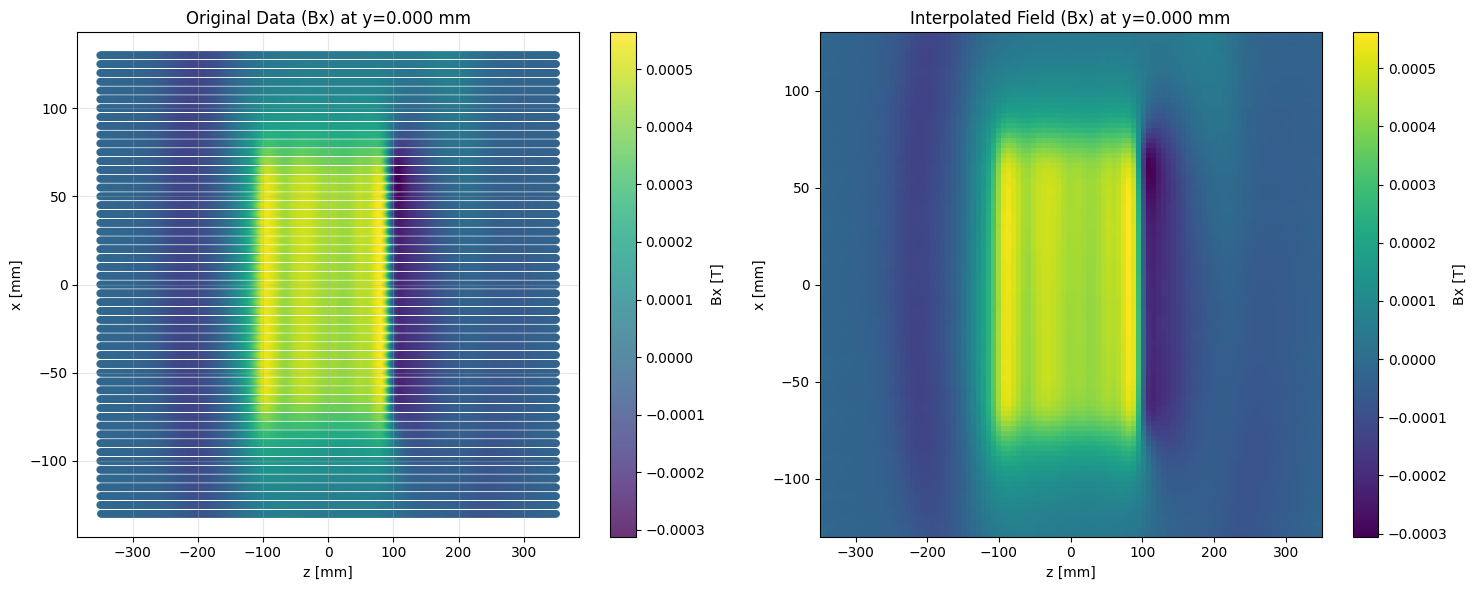

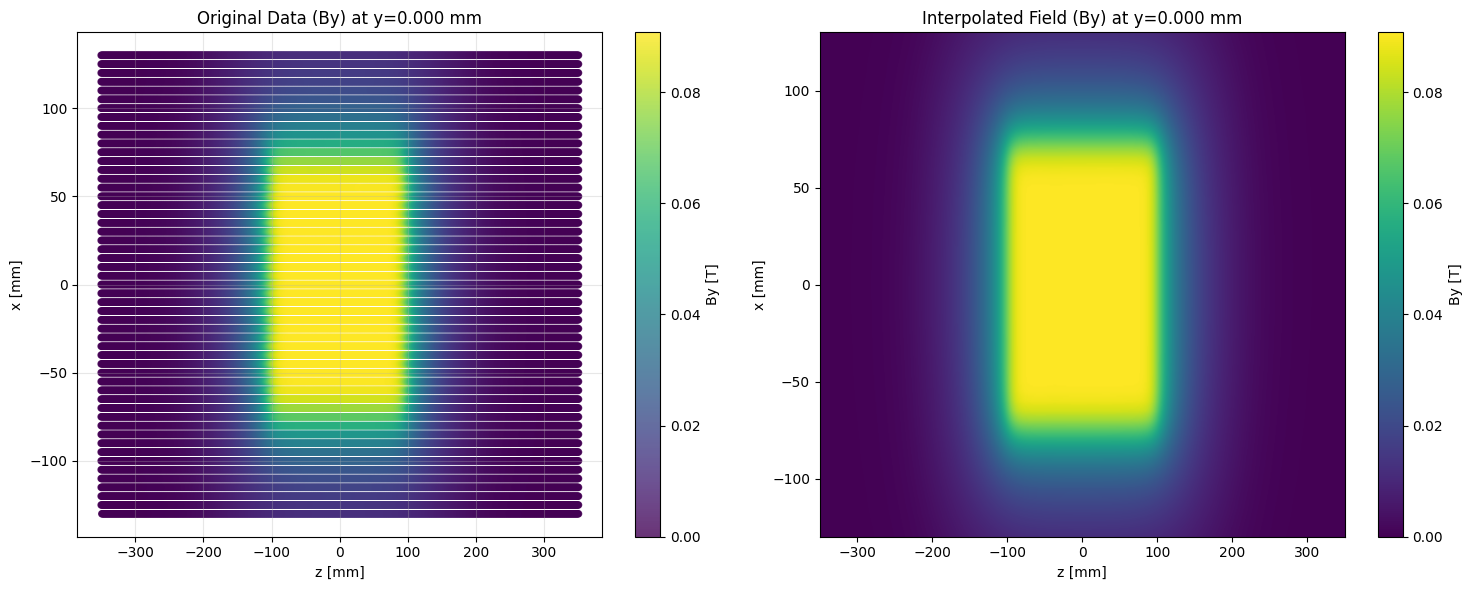

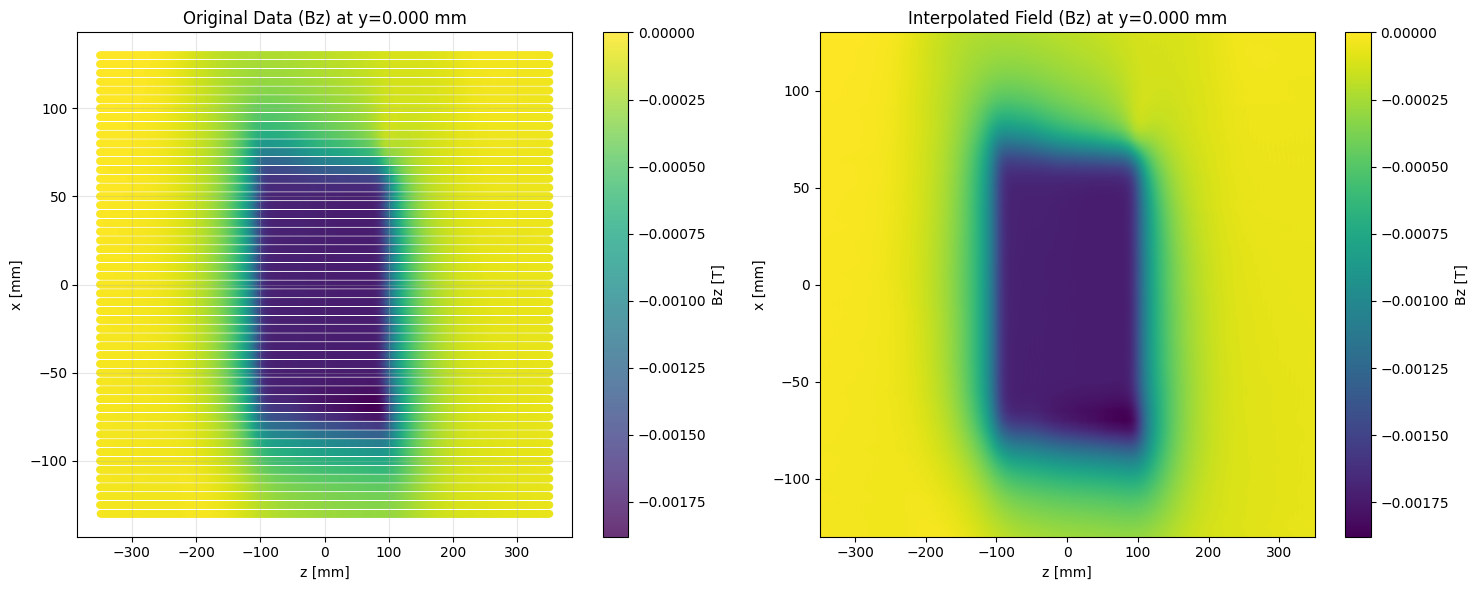

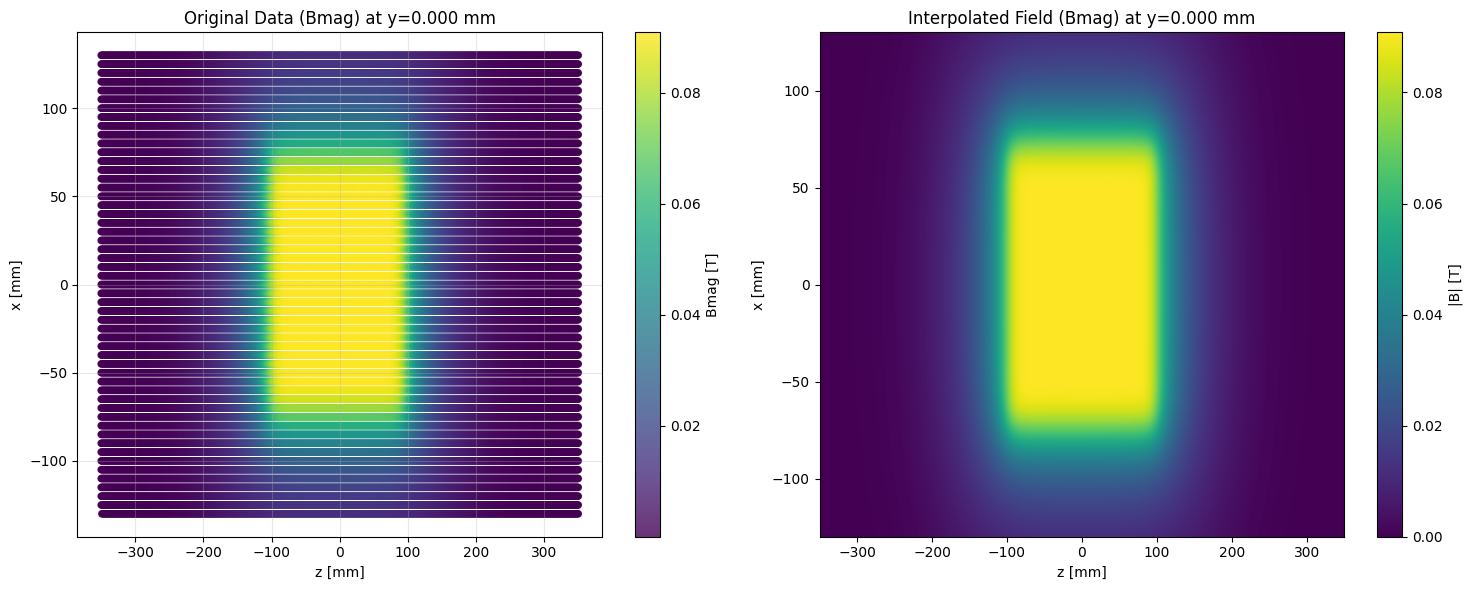

In [19]:
# data import
df = pd.read_csv('2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=2.5A_ID=5481.dat', sep='\t', skiprows=16)
# some adjusts
df = df.dropna(axis=1)
df = df.set_axis(["x_mm", "y_mm", "z_mm", "Bx_T", "By_T", "Bz_T"], axis=1)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()



field_plot(df)